# Import

In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNetCV, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
# Clustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering

In [292]:
train_df = pd.read_csv("data/donapp2.csv", header=0, sep="\t", decimal=",")
test_df = pd.read_csv("data/dontest.csv", header=0, sep=",")

# Preprocessing

## Vérification de l'intégrité des données

In [293]:
train_df.head(5)

,Pitch_angle,Pitch_angle_std,Hub_temperature,Hub_temperature_std,Generator_converter_speed,Generator_converter_speed_std,Generator_speed,Generator_speed_std,Generator_bearing_1_temperature,Generator_bearing_1_temperature_std,...,Grid_frequency,Grid_frequency_std,Rotor_speed,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_std,Nacelle_angle_c,AbsWindSin,AbsWindCos,Y
16108,-1.000000,0.0,28.00,0.04,1556.25000,34.669998,1557.81990,34.740002,47.970001,0.28,...,50.020000,0.01,14.82,0.33,39.500000,0.01,270.609990,-0.987634,0.156779,519.739989
15683,-1.000000,0.0,20.02,0.19,1231.77000,30.799999,1233.03000,30.870001,44.560001,0.26,...,49.990002,0.01,11.72,0.30,32.639999,0.04,352.290010,-0.102272,0.994757,228.867000
7800,-1.000000,0.0,16.52,0.42,1463.75000,101.490000,1464.93990,101.670000,37.650002,0.74,...,49.980000,0.01,13.93,0.97,34.349998,0.07,189.850010,-0.204838,-0.978796,444.972989
12843,-1.010000,0.0,9.00,0.00,993.72998,16.850000,993.70001,16.879999,21.670000,0.08,...,49.970001,0.01,9.43,0.16,15.850000,0.15,73.510002,0.921796,0.387676,92.115002
10051,44.990002,0.0,29.00,0.00,2.68000,0.010000,0.00000,0.050000,46.230000,0.07,...,49.990002,0.01,0.00,0.00,34.020000,0.08,36.200001,0.867765,0.496974,-1.319000


In [294]:
train_df.dtypes

Pitch_angle                            float64
Pitch_angle_std                        float64
Hub_temperature                        float64
Hub_temperature_std                    float64
Generator_converter_speed              float64
Generator_converter_speed_std          float64
Generator_speed                        float64
Generator_speed_std                    float64
Generator_bearing_1_temperature        float64
Generator_bearing_1_temperature_std    float64
Generator_bearing_2_temperature        float64
Generator_bearing_2_temperature_std    float64
Generator_stator_temperature           float64
Generator_stator_temperature_std       float64
Gearbox_bearing_1_temperature          float64
Gearbox_bearing_1_temperature_std      float64
Gearbox_bearing_2_temperature          float64
Gearbox_bearing_2_temperature_std      float64
Gearbox_inlet_temperature              float64
Gearbox_inlet_temperature_std          float64
Gearbox_oil_sump_temperature           float64
Gearbox_oil_s

In [295]:
test_df.head(5)

,Pitch_angle,Pitch_angle_std,Hub_temperature,Hub_temperature_std,Generator_converter_speed,Generator_converter_speed_std,Generator_speed,Generator_speed_std,Generator_bearing_1_temperature,Generator_bearing_1_temperature_std,...,Grid_frequency,Grid_frequency_std,Rotor_speed,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_std,Nacelle_angle_c,AbsWindSin,AbsWindCos,Y
0,-1.010000,0.0,20.969999,0.23,1423.75000,63.220001,1424.68990,63.330002,40.160000,0.24,...,50.049999,0.01,13.55,0.60,35.619999,0.02,241.440000,-0.799789,-0.600281,385.199000
1,89.980003,0.0,22.000000,0.00,2.98000,0.010000,0.00000,0.000000,39.860001,0.09,...,50.000000,0.01,0.00,0.00,30.590000,0.10,79.000000,0.570714,0.821149,-4.454000
2,91.949997,0.0,26.000000,0.00,2.85000,0.010000,0.00000,0.000000,37.970001,0.11,...,50.020000,0.01,0.00,0.00,27.959999,0.04,52.660000,-0.814217,-0.580561,-2.001000
3,-1.000000,0.0,22.000000,0.02,1447.54000,69.230003,1448.60000,69.360001,42.439999,0.19,...,49.980000,0.01,13.78,0.66,28.410000,0.21,280.950010,-0.942233,0.334958,409.619011
4,-1.000000,0.0,13.000000,0.00,992.89001,57.000000,993.65997,57.130001,35.430000,0.15,...,50.009998,0.01,9.43,0.55,25.940001,0.02,65.830002,0.976220,0.216780,90.850000


In [296]:
test_df.dtypes

Pitch_angle                            float64
Pitch_angle_std                        float64
Hub_temperature                        float64
Hub_temperature_std                    float64
Generator_converter_speed              float64
Generator_converter_speed_std          float64
Generator_speed                        float64
Generator_speed_std                    float64
Generator_bearing_1_temperature        float64
Generator_bearing_1_temperature_std    float64
Generator_bearing_2_temperature        float64
Generator_bearing_2_temperature_std    float64
Generator_stator_temperature           float64
Generator_stator_temperature_std       float64
Gearbox_bearing_1_temperature          float64
Gearbox_bearing_1_temperature_std      float64
Gearbox_bearing_2_temperature          float64
Gearbox_bearing_2_temperature_std      float64
Gearbox_inlet_temperature              float64
Gearbox_inlet_temperature_std          float64
Gearbox_oil_sump_temperature           float64
Gearbox_oil_s

In [297]:
# Montrer les colonnes avec des valeurs manquantes
train_df.isna().sum()[train_df.isna().sum() > 0]

Series([], dtype: int64)

In [298]:
test_df.isna().sum()[test_df.isna().sum() > 0]

Series([], dtype: int64)

pas de NA, parfait

## Réduction de dimension

In [299]:
# Afficher les dimensions des datasets
print(f"Train dataset dimensions: {train_df.shape}")
print(f"Test dataset dimensions: {test_df.shape}")

Train dataset dimensions: (10000, 36)
Test dataset dimensions: (5000, 36)


On retire les colonnes _std : l'écart-type indique la qualité des données mais ne porte pas d'informations pour la prévision.

In [300]:
train_df.drop(columns=[col for col in train_df.columns if col.endswith(('_std'))],inplace=True)
test_df.drop(columns=[col for col in test_df.columns if col.endswith(('_std'))],inplace=True)

train_df.head(1)

,Pitch_angle,Hub_temperature,Generator_converter_speed,Generator_speed,Generator_bearing_1_temperature,Generator_bearing_2_temperature,Generator_stator_temperature,Gearbox_bearing_1_temperature,Gearbox_bearing_2_temperature,Gearbox_inlet_temperature,Gearbox_oil_sump_temperature,Nacelle_angle,Absolute_wind_direction,Grid_frequency,Rotor_speed,Rotor_bearing_temperature,Nacelle_angle_c,AbsWindSin,AbsWindCos,Y
16108,-1.0,28.0,1556.25,1557.8199,47.970001,42.549999,64.540001,63.98,68.860001,51.189999,57.16,270.60999,279.01999,50.02,14.82,39.5,270.60999,-0.987634,0.156779,519.739989


In [301]:
# Afficher les dimensions des datasets
print(f"Train dataset dimensions: {train_df.shape}")
print(f"Test dataset dimensions: {test_df.shape}")

Train dataset dimensions: (10000, 20)
Test dataset dimensions: (5000, 20)


### Recherche de corrélations

In [302]:
# Matrice de corrélation entre les variables
corr_matrix = train_df.corr()
# Représenter la matrice avec un gradient de couleurs
corr_matrix.style.background_gradient(cmap='coolwarm')


,Pitch_angle,Hub_temperature,Generator_converter_speed,Generator_speed,Generator_bearing_1_temperature,Generator_bearing_2_temperature,Generator_stator_temperature,Gearbox_bearing_1_temperature,Gearbox_bearing_2_temperature,Gearbox_inlet_temperature,Gearbox_oil_sump_temperature,Nacelle_angle,Absolute_wind_direction,Grid_frequency,Rotor_speed,Rotor_bearing_temperature,Nacelle_angle_c,AbsWindSin,AbsWindCos,Y
Pitch_angle,1.000000,-0.154809,-0.826700,-0.826778,-0.552642,-0.580891,-0.716985,-0.820131,-0.804020,-0.695099,-0.712428,-0.024387,-0.024023,-0.076503,-0.826194,-0.621214,-0.024385,0.105099,0.059539,-0.377733
Hub_temperature,-0.154809,1.000000,-0.001443,-0.001417,0.539058,0.608548,0.337309,0.258115,0.229209,0.402902,0.378770,0.073670,0.066111,0.015272,-0.001597,0.703466,0.073675,-0.036959,-0.069136,-0.095595
Generator_converter_speed,-0.826700,-0.001443,1.000000,0.999995,0.334805,0.333693,0.615386,0.841968,0.856237,0.476623,0.614870,0.027704,0.033420,0.046166,0.999994,0.555324,0.027702,-0.168941,-0.104420,0.738498
Generator_speed,-0.826778,-0.001417,0.999995,1.000000,0.334980,0.333830,0.615577,0.842077,0.856344,0.476753,0.614998,0.027751,0.033406,0.046202,0.999997,0.555451,0.027749,-0.168963,-0.104542,0.738461
Generator_bearing_1_temperature,-0.552642,0.539058,0.334805,0.334980,1.000000,0.913680,0.834251,0.669232,0.670729,0.846134,0.834082,0.084988,0.077469,0.018411,0.334582,0.792002,0.084988,-0.099615,-0.024884,-0.043011
Generator_bearing_2_temperature,-0.580891,0.608548,0.333693,0.333830,0.913680,1.000000,0.859178,0.693204,0.676206,0.825727,0.824946,0.067328,0.059277,0.016514,0.333511,0.830177,0.067329,-0.080096,-0.040110,0.036888
Generator_stator_temperature,-0.716985,0.337309,0.615386,0.615577,0.834251,0.859178,1.000000,0.882683,0.877645,0.794249,0.897873,0.066676,0.063150,0.020731,0.615416,0.821365,0.066674,-0.135976,-0.043008,0.376222
Gearbox_bearing_1_temperature,-0.820131,0.258115,0.841968,0.842077,0.669232,0.693204,0.882683,1.000000,0.989200,0.777064,0.899122,0.065911,0.063540,0.030919,0.842068,0.819684,0.065909,-0.175473,-0.091731,0.593474
Gearbox_bearing_2_temperature,-0.804020,0.229209,0.856237,0.856344,0.670729,0.676206,0.877645,0.989200,1.000000,0.769525,0.910453,0.068415,0.066515,0.031376,0.856371,0.817328,0.068413,-0.184510,-0.088754,0.596560
Gearbox_inlet_temperature,-0.695099,0.402902,0.476623,0.476753,0.846134,0.825727,0.794249,0.777064,0.769525,1.000000,0.928824,0.073909,0.069990,0.047159,0.476217,0.773871,0.073905,-0.117347,-0.028623,0.040751


In [303]:
# Afficher les corrélations supérieures à 0.9
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr > 0.9]
# Retirer les corrélations redondantes et les auto-corrélations
high_corr = high_corr[high_corr < 1].drop_duplicates()
print("Correlations fortes (>|0.9|):")
print(high_corr)


Correlations fortes (>|0.9|):
Nacelle_angle_c                  Nacelle_angle                      1.000000
Generator_speed                  Rotor_speed                        0.999997
                                 Generator_converter_speed          0.999995
Rotor_speed                      Generator_converter_speed          0.999994
Gearbox_bearing_2_temperature    Gearbox_bearing_1_temperature      0.989200
Gearbox_inlet_temperature        Gearbox_oil_sump_temperature       0.928824
Generator_bearing_2_temperature  Generator_bearing_1_temperature    0.913680
Gearbox_bearing_2_temperature    Gearbox_oil_sump_temperature       0.910453
dtype: float64


In [304]:
# Supprimer la variable Nacelle_angle qui est égale à Nacelle_angle_c
train_df.drop(columns=['Nacelle_angle'], inplace=True)
test_df.drop(columns=['Nacelle_angle'], inplace=True)

In [305]:
# Créer des jeux de données allégées
train_df_light = train_df.copy()
test_df_light = test_df.copy()

train_df_light.drop(columns=['Rotor_speed',
'Generator_converter_speed',
'Gearbox_bearing_1_temperature',
'Gearbox_oil_sump_temperature',
'Generator_bearing_1_temperature',
'Gearbox_oil_sump_temperature'],inplace=True)

test_df_light.drop(columns=['Rotor_speed',
'Generator_converter_speed',
'Gearbox_bearing_1_temperature',
'Gearbox_oil_sump_temperature',
'Generator_bearing_1_temperature',
'Gearbox_oil_sump_temperature'],inplace=True)

In [306]:
# Vérifier les corrélations
corr_matrix = train_df_light.corr()
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr > 0.9]
high_corr = high_corr[high_corr < 1].drop_duplicates()
print("Correlations fortes (>|0.9|):")
print(high_corr)

Correlations fortes (>|0.9|):
Series([], dtype: float64)


In [307]:
# Afficher les dimensions des datasets
print(f"Train dataset dimensions: {train_df.shape}")
print(f"Test dataset dimensions: {test_df.shape}")
print(f"Train light dataset dimensions: {train_df_light.shape}")
print(f"Test light dataset dimensions: {test_df_light.shape}")

Train dataset dimensions: (10000, 19)
Test dataset dimensions: (5000, 19)
Train light dataset dimensions: (10000, 14)
Test light dataset dimensions: (5000, 14)


In [308]:
# Réinitialiser les indexs
train_df.reset_index(drop=True,inplace=True)
test_df.reset_index(drop=True,inplace=True)
train_df_light.reset_index(drop=True,inplace=True)
test_df_light.reset_index(drop=True,inplace=True)

# ML

## Etape 1 : Choix de la méthode de régression

### Definitions de fonctions

In [309]:
#Fonction pour calculer l'erreur quadratique moyenne
def apply_erreur(RES):
    return RES.apply(lambda col: round(mean_squared_error(col, RES.iloc[:, 0]),2), axis=0)

In [310]:
# Fonction qui retourne les prédictions pour chaque méthode de régression
def get_predictions(train_df):
    # Initialisation de KFold
    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    # Création d'un dataframe pour comparer les résultats de chaque méthode (n blocs)
    PREV = pd.DataFrame(
        {
            "Y": train_df["Y"]
        }
    )

    for i, (train_index, val_index) in enumerate(kf.split(train_df)):

        # Séparation des données en train et test
        X_train = train_df.iloc[train_index].drop(["Y"], axis=1)
        X_val = train_df.iloc[val_index].drop(["Y"], axis=1)
        Y_train = train_df.iloc[train_index]["Y"]
        Y_val= train_df.iloc[val_index]["Y"]

        # Régression linéaire (MCO)
        reg = LinearRegression()
        reg.fit(X_train, Y_train)
        PREV.loc[val_index, "MCO"] = reg.predict(X_val)

        # Définition d'un nouveau kf pour la validation croisée de lambda
        kf_lambda = KFold(n_splits=10, shuffle=True, random_state=0)

        # Lasso avec validation croisée
        lassocv = LassoCV(cv=kf_lambda)
        pipelassocv = Pipeline(steps=[("cr", StandardScaler()), ("lassocv", lassocv)])
        pipelassocv.fit(X_train, Y_train)
        PREV.loc[val_index, "lasso"] = pipelassocv.predict(X_val)

        # Ridge avec validation croisée
        grilleridge = lassocv.alphas_ * 100
        ridgecv = RidgeCV(cv=kf_lambda, alphas=grilleridge)
        piperidgecv = Pipeline(steps=[("cr", StandardScaler()), ("ridgecv", ridgecv)])
        piperidgecv.fit(X_train, Y_train)
        PREV.loc[val_index, "ridge"] = piperidgecv.predict(X_val)

        # ElasticNet avec validation croisée
        grilleelas = lassocv.alphas_ * 2
        elasticcv = ElasticNetCV(cv=kf_lambda, alphas=grilleelas)
        pipeelasticcv = Pipeline(steps=[("cr", StandardScaler()), ("elasticcv", elasticcv)])
        pipeelasticcv.fit(X_train, Y_train)
        PREV.loc[val_index, "elas"] = pipeelasticcv.predict(X_val)

        # Arbre de décision
        arbre = DecisionTreeRegressor()
        arbre.fit(X_train, Y_train)
        PREV.loc[val_index, "arbre"] = arbre.predict(X_val)

        # Forêt aléatoire
        foret = RandomForestRegressor()
        foret.fit(X_train, Y_train)
        PREV.loc[val_index, "foret"] = foret.predict(X_val)

        # HistGradientBoostingRegressor
        hgb = HistGradientBoostingRegressor(early_stopping=True, tol=1e-4)
        hgb.fit(X_train, Y_train)
        PREV.loc[val_index, "hgb"] = hgb.predict(X_val)

        # XGBoost
        xgb = XGBRegressor(objective='reg:squarederror', n_estimators=1000, early_stopping_rounds=10)
        xgb.fit(X_train, Y_train, eval_set=[(X_val, Y_val)], verbose=False)
        PREV.loc[val_index, "xgb"] = xgb.predict(X_val)

        # Support Vector Regression
        svr = SVR()
        pipesvr = Pipeline(steps=[("cr", StandardScaler()), ("svr", svr)])
        pipesvr.fit(X_train, Y_train)
        PREV.loc[val_index, "svr"] = pipesvr.predict(X_val)
    
    erreurs = apply_erreur(PREV)
    return PREV, erreurs

In [311]:
# Fonction pour tracer les prédictions et le tableau des erreurs
def plot_prev(PREV,erreurs):
    # Création de la figure avec deux sous-graphiques
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Sous-graphe 1 : Comparaison des prédictions des modèles
    for col in ["MCO", "ridge", "lasso", "elas", "arbre", "foret","hgb","xgb","svr"]:
        ax[0].scatter(PREV["Y"], PREV[col], label=col, alpha=0.6)

    ax[0].plot(
        [PREV["Y"].min(), PREV["Y"].max()],
        [PREV["Y"].min(), PREV["Y"].max()],
        "k--",
        lw=2,
        label="Valeurs réelles",
    )
    ax[0].set_xlabel("Valeurs réelles (Y)")
    ax[0].set_ylabel("Estimations")
    ax[0].set_title("Comparaison des estimations des modèles")
    ax[0].legend()

    # Sous-graphe 2 : Tableau des erreurs
    erreurs = erreurs.drop("Y")
    # Conversion des erreurs en DataFrame pour affichage
    erreurs_df = erreurs.reset_index()
    erreurs_df.columns = ["Modèle", "MSE"]

    # Création du tableau
    ax[1].axis("tight")
    ax[1].axis("off")
    table = ax[1].table(
        cellText=erreurs_df.values,
        colLabels=erreurs_df.columns,
        cellLoc="center",
        loc="center",
    )
    # Highlight de la meilleure erreur
    best_model_idx = erreurs.idxmin()
    for i in range(len(erreurs_df)):
        if erreurs_df.iloc[i, 0] == best_model_idx:
            table[(i + 1, 1)].set_facecolor("lightgreen")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(erreurs_df.columns))))

    # Affichage de la figure
    plt.tight_layout()
    plt.show()

### Calculs de prédiction

In [312]:
# Calcul des prédictions
prev_train, erreurs_train = get_predictions(train_df)
prev_train_light, erreurs_train_light = get_predictions(train_df_light)

/home/user/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.867e+06, tolerance: 1.772e+05
  model = cd_fast.enet_coordinate_descent(
/home/user/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.221e+06, tolerance: 1.742e+05
  model = cd_fast.enet_coordinate_descent(
/home/user/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality 

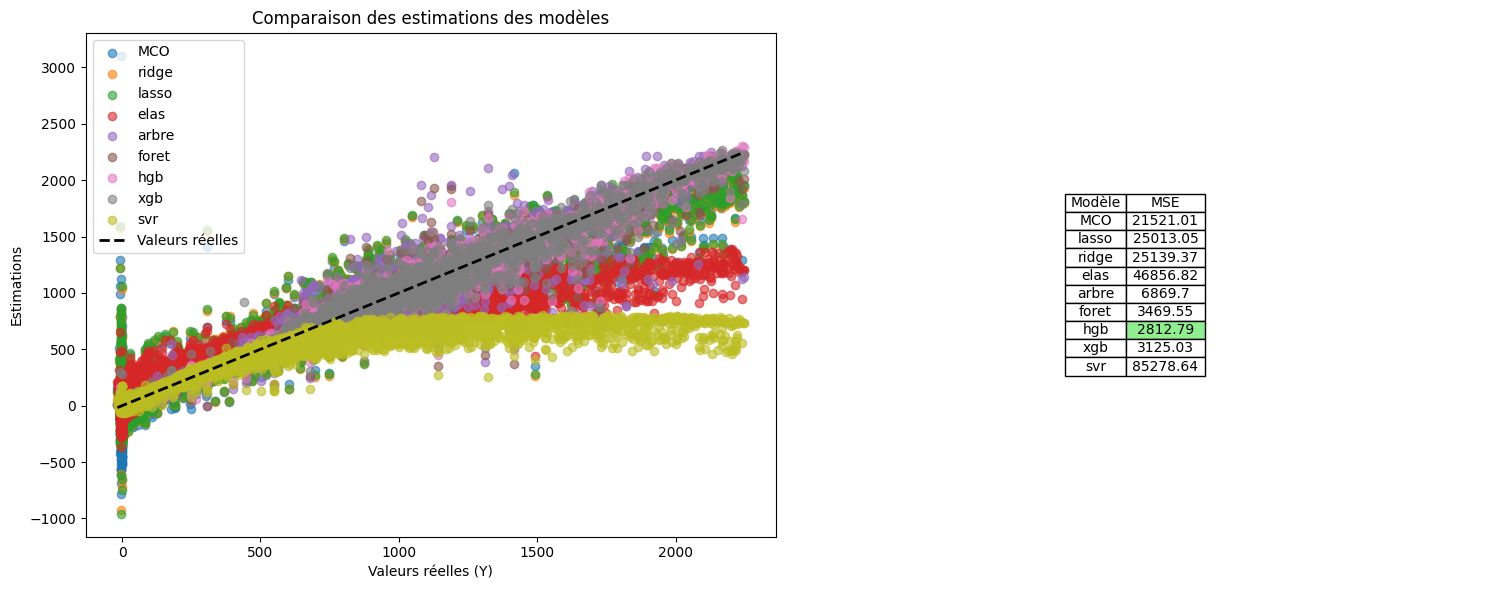

In [313]:
plot_prev(prev_train,erreurs_train)

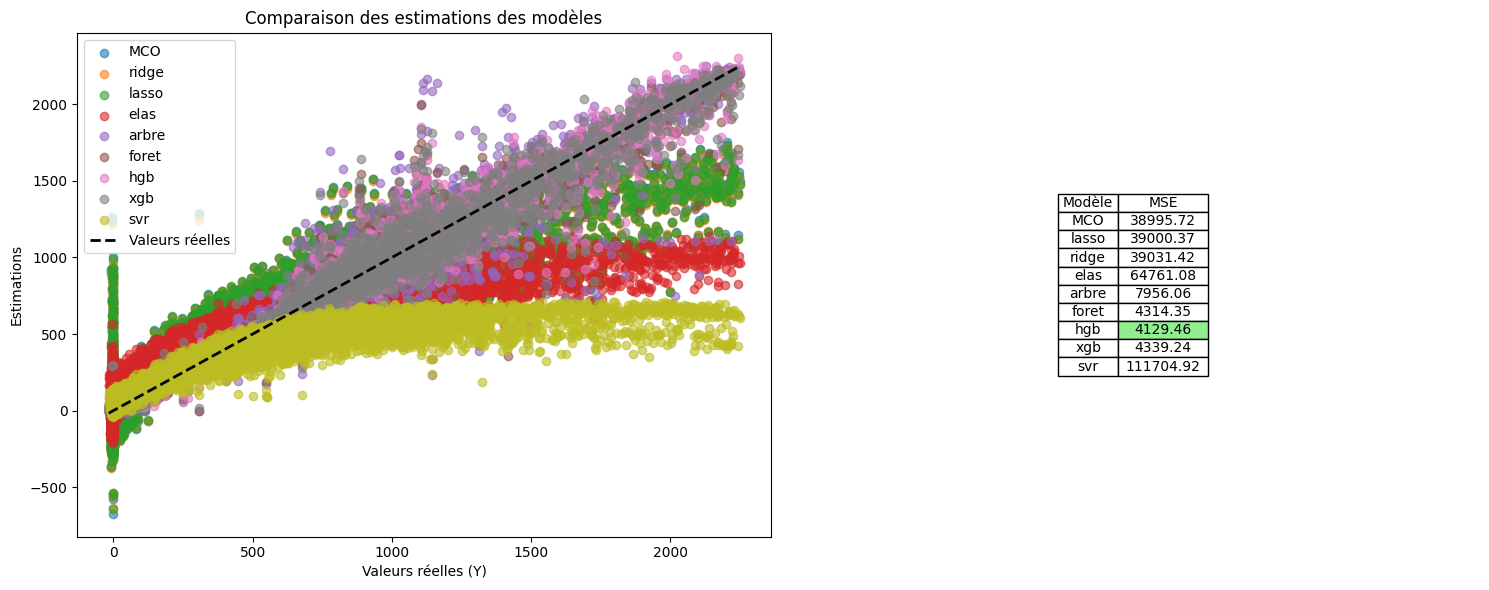

In [314]:
plot_prev(prev_train_light,erreurs_train_light)

==> Le HistGradientBoosting gagne, et sur le jeu de données exhaustif

### Ré-entraînement de la meilleure méthode de régression sur tout le jeu d'apprentissage

In [315]:
X_train=train_df.drop(["Y"], axis=1)
y_train=train_df["Y"]

X_test=test_df.drop(["Y"], axis=1)
y_test=test_df["Y"]

In [316]:
hgb = HistGradientBoostingRegressor(early_stopping=True, tol=1e-4)
hgb.fit(X_train, y_train)
final_train_mse = mean_squared_error(hgb.predict(X_train), y_train)
print(f"MSE d'entraînement final HGB : {final_train_mse}")
final_test_mse = mean_squared_error(hgb.predict(X_test), y_test)
print(f"MSE de test final HGB : {final_test_mse}")

MSE d'entraînement final HGB : 886.2483309154367
MSE de test final HGB : 2434.2883822746303


Petit problème de surapprentissage, mais l'erreur est correcte.

### Fine tuning du Hist Gradient Boosting

In [317]:
gb_model = HistGradientBoostingRegressor(early_stopping=True, tol=1e-4)

params_gb = {
    'max_iter': [2000],
    'learning_rate': [0.05, 0.1, 0.15, 0.2, 0.25],
    'loss': ['squared_error', 'absolute_error']
}

gb = GridSearchCV(estimator  = gb_model,
                  param_grid = params_gb,
                  scoring    = 'neg_mean_squared_error',
                  cv         = 10,
                  n_jobs     = -1,
                  verbose    = 1)

gb.fit(X_train, y_train)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


,estimator,"HistGradientB...e, tol=0.0001)"
,param_grid,"{'learning_rate': [0.05, 0.1, ...], 'loss': ['squared_error', 'absolute_error'], 'max_iter': [2000]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [318]:
# Recalcul de HGB avec le best estimator sur tout le jeu de train
final_hgb = gb.best_estimator_
final_hgb.fit(X_train, y_train)
final_train_mse = mean_squared_error(final_hgb.predict(X_train), y_train)
print(f"MSE d'entraînement final HGB après GridSearchCV : {final_train_mse}")
final_test_mse = mean_squared_error(final_hgb.predict(X_test), y_test)
print(f"MSE de test final HGB après GridSearchCV : {final_test_mse}")

MSE d'entraînement final HGB après GridSearchCV : 924.40680907127
MSE de test final HGB après GridSearchCV : 2450.310873003161


Le fine tuning améliore la performance sur le jeu d'apprentissage mais la dégrade sur le jeu de test, il est donc inutile voire néfaste.

## Etape 2 : Clustering

fonction d'affichage de dendogramme

In [319]:
def plot_dendrogram(model, **kwargs):
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    
    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

### Modèle CAH

In [328]:
cah_model = AgglomerativeClustering(metric='euclidean', linkage='ward', distance_threshold=0, n_clusters=None)
cah_out = cah_model.fit(X_train)

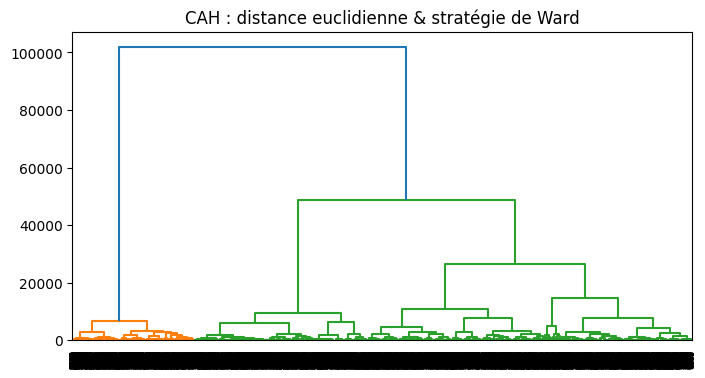

In [329]:
plt.subplots(figsize=(8, 4))
plot_dendrogram(cah_out, truncate_mode='level')
plt.title('CAH : distance euclidienne & stratégie de Ward')
plt.show()

On distingue 1 groupe orange et 1 groupe vert, on va vérifier ça en traçant les hauteurs

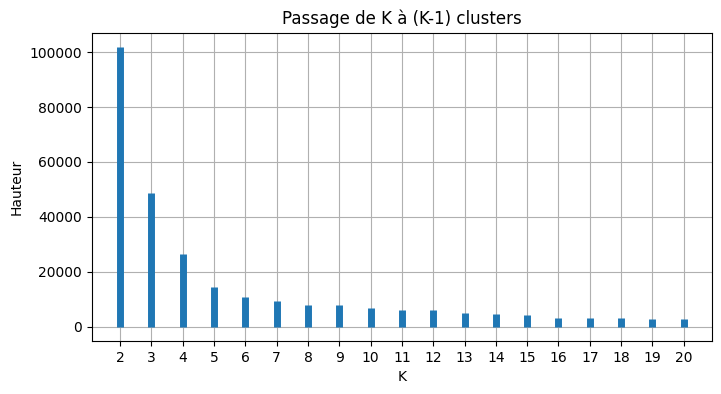

In [330]:
k_max = 20

fig, ax = plt.subplots(figsize=(8, 4))
ax.vlines(range(2, k_max+1), 0, np.flip(np.sort(cah_out.distances_))[0:k_max-1], linewidth=5)
ax.set_xticks(range(2, k_max+1))
ax.grid()
ax.set_xlabel('K')
ax.set_ylabel('Hauteur')
plt.title('Passage de K à (K-1) clusters')
plt.show()

Le choix de 2 groupes respecte la règle du coude, on va voir combien d'individus ça représente.

In [337]:
k = 2

cah_model = AgglomerativeClustering(metric='euclidean', linkage='ward', n_clusters=k)
cah_out = cah_model.fit(X_train)

In [338]:
# Appliquer le clustering sur le jeu de train
clusters_train = pd.DataFrame()
clusters_train['cluster_cah_ward'] = cah_out.fit_predict(X_train)
clusters_train['cluster_cah_ward'].value_counts()

cluster_cah_ward
0    8035
1    1965
Name: count, dtype: int64

In [339]:
# Appliquer le clustering sur le jeu de test
clusters_test = pd.DataFrame()
clusters_test['cluster_cah_ward'] = cah_out.fit_predict(X_test)
clusters_test['cluster_cah_ward'].value_counts()

cluster_cah_ward
0    3916
1    1084
Name: count, dtype: int64

In [340]:
# Appliquer le HGB sur chaque cluster et afficher l'erreur d'estimation
for cluster_id in range(k):
    
    cluster_indices_train = clusters_train[clusters_train['cluster_cah_ward'] == cluster_id].index
    X_train_cluster = X.iloc[cluster_indices_train]
    y_train_cluster = y.iloc[cluster_indices_train]

    cluster_indices_test = clusters_test[clusters_test['cluster_cah_ward'] == cluster_id].index
    X_test_cluster = X_test.iloc[cluster_indices_test]
    y_test_cluster = y_test.iloc[cluster_indices_test]

    hgb_cluster = HistGradientBoostingRegressor(early_stopping=True, tol=1e-4)
    hgb_cluster.fit(X_train_cluster, y_train_cluster)
    
    train_mse = mean_squared_error(hgb_cluster.predict(X_train_cluster), y_train_cluster)
    print(f"Cluster {cluster_id}: MSE d'apprentissage = {train_mse}")
    test_mse = mean_squared_error(hgb_cluster.predict(X_test_cluster), y_test_cluster)
    print(f"Cluster {cluster_id}: MSE de test = {test_mse}")

Cluster 0: MSE d'apprentissage = 1186.5440428502834
Cluster 0: MSE de test = 3243.4120414825975
Cluster 1: MSE d'apprentissage = 0.29727205572941656
Cluster 1: MSE de test = 81.96833472512941


Le modèle HGB est très bon sur le cluster 1, mais moins bon sur le cluster 0 que sur les données non clusterisées.